# Parte 3: Metodología Box-Jenkins (PIB del Reino Unido)

El presente análisis tiene como objetivo modelar y caracterizar la dinámica temporal del Producto Interno Bruto (GDP) del Reino Unido utilizando la metodología Box-Jenkins, con énfasis en la identificación, estimación y validación de modelos ARIMA.

El alcance del ejercicio es de carácter descriptivo y econométrico, orientado a evaluar la estacionariedad de la serie, determinar su orden de integración y proponer especificaciones ARIMA adecuadas en función de la evidencia empírica observada en los gráficos, correlogramas (ACF y PACF) y test estadísticos.

En una primera etapa, se analiza la serie en nivel, evaluando su comportamiento temporal y la presencia de persistencia mediante herramientas gráficas y el test de Dickey-Fuller aumentado. Posteriormente, se aplica una transformación en logaritmos y se calcula la primera diferencia logarítmica, con el objetivo de inducir estacionariedad y facilitar la modelación.

A partir de este diagnóstico, se identifican modelos ARIMA candidatos, los cuales son estimados y comparados utilizando criterios de información (AIC y BIC), significancia estadística de parámetros, significancia global del modelo y propiedades de los residuos, incluyendo independencia, ausencia de autocorrelación y comportamiento compatible con ruido blanco.

El análisis se limita a una evaluación dentro de muestra, lo que implica que los resultados obtenidos reflejan la capacidad del modelo para explicar la dinámica histórica de la serie. No obstante, se discuten las limitaciones de este enfoque y la importancia de complementar el análisis con evaluaciones fuera de muestra para validar capacidad predictiva.

En consecuencia, el alcance de esta sección se centra en la correcta aplicación de la metodología Box-Jenkins, la interpretación rigurosa de los resultados y la validación estadística de los modelos estimados, más que en la generación de pronósticos de largo plazo.

### Bloque 0 - Importar Librerias

In [58]:
import os
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_ljungbox

### Bloque 1 - Cargar base GDP UK

In [59]:
BASE_DIR = Path(r"C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0011\Tarea Final")
DATA_DIR = BASE_DIR / "dataset"
RESULTS_DIR = BASE_DIR / "results"
GRAPHICS_DIR = RESULTS_DIR / "graphics"/"parte3"
TABLES_DIR = RESULTS_DIR / "tables" /"parte3"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
GRAPHICS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

archivo = os.path.join(DATA_DIR, "gdp_uk.xlsx")

df_gdp = pd.read_excel(archivo)

df_gdp.columns = (
    df_gdp.columns.astype(str)
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print(df_gdp.head())
print(df_gdp.columns)

   1980q1  72.2
0  1980Q2  70.8
1  1980Q3  70.5
2  1980Q4  69.7
3  1981Q1  69.4
4  1981Q2  69.5
Index(['1980q1', '72.2'], dtype='str')


### Bloque 2 - Preparar fecha trimestral y serie GDP

In [60]:
# Ajusta estos nombres si tu archivo tiene columnas distintas
if "date" in df_gdp.columns:
    fecha_col = "date"
elif "fecha" in df_gdp.columns:
    fecha_col = "fecha"
elif "quarter" in df_gdp.columns:
    fecha_col = "quarter"
else:
    fecha_col = df_gdp.columns[0]

if "gdp" in df_gdp.columns:
    gdp_col = "gdp"
else:
    gdp_col = df_gdp.columns[1]

df_gdp = df_gdp[[fecha_col, gdp_col]].copy()
df_gdp = df_gdp.rename(columns={fecha_col: "fecha", gdp_col: "gdp"})

df_gdp["fecha"] = df_gdp["fecha"].astype(str).str.replace("Q", "Q", regex=False)

try:
    df_gdp["fecha"] = pd.PeriodIndex(df_gdp["fecha"], freq="Q").to_timestamp()
except:
    df_gdp["fecha"] = pd.to_datetime(df_gdp["fecha"], errors="coerce")

df_gdp = df_gdp.dropna(subset=["fecha", "gdp"])
df_gdp = df_gdp.sort_values("fecha")
df_gdp = df_gdp.set_index("fecha")

df_gdp["log_gdp"] = np.log(df_gdp["gdp"])
df_gdp["dlog_gdp"] = df_gdp["log_gdp"].diff()

print("Rango temporal:", df_gdp.index.min(), "a", df_gdp.index.max())
print("Observaciones:", len(df_gdp))

df_gdp.head()

Rango temporal: 1980-04-01 00:00:00 a 1998-04-01 00:00:00
Observaciones: 73


,gdp,log_gdp,dlog_gdp
fecha,,,
1980-04-01,70.8,4.259859,NaN
1980-07-01,70.5,4.255613,-0.004246
1980-10-01,69.7,4.244200,-0.011412
1981-01-01,69.4,4.239887,-0.004313
1981-04-01,69.5,4.241327,0.001440


# Pregunta A: GDP en nivel, ACF y PACF
### Bloque 3 - Gráfico GDP nivel + ACF + PACF

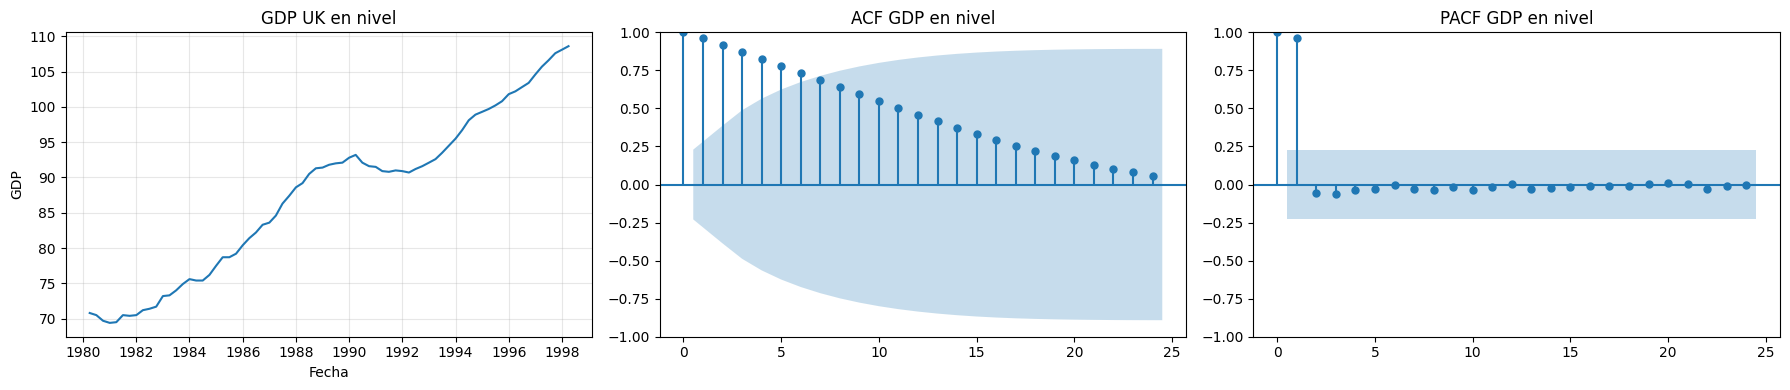

In [61]:
serie = df_gdp["gdp"].dropna()

fig, ax = plt.subplots(1, 3, figsize=(18, 4))

ax[0].plot(serie.index, serie)
ax[0].set_title("GDP UK en nivel")
ax[0].set_xlabel("Fecha")
ax[0].set_ylabel("GDP")
ax[0].grid(True, alpha=0.3)

plot_acf(serie, lags=24, ax=ax[1])
ax[1].set_title("ACF GDP en nivel")

plot_pacf(serie, lags=24, ax=ax[2], method="ywm")
ax[2].set_title("PACF GDP en nivel")

plt.tight_layout()
plt.savefig(os.path.join(GRAPHICS_DIR, "grafico_1_GDP_ACF_PACF.png"))
plt.show()

### Bloque 4 - Test ADF en nivel

In [62]:
adf_nivel = adfuller(df_gdp["gdp"].dropna(), autolag="AIC")

print("ADF GDP nivel")
print("Estadístico ADF:", adf_nivel[0])
print("p-value:", adf_nivel[1])
print("Rechaza raíz unitaria al 5%:", adf_nivel[1] < 0.05)

ADF GDP nivel
Estadístico ADF: -0.6066672070831256
p-value: 0.8694683832274569
Rechaza raíz unitaria al 5%: False


## Respuesta A

La serie GDP en nivel muestra un comportamiento altamente persistente. El autocorrelograma presenta un decaimiento lento, lo que sugiere que la serie no es estacionaria o que posee una raíz unitaria.

Este patrón es típico de series macroeconómicas en nivel, donde los shocks tienden a tener efectos persistentes. La evidencia visual del gráfico y de la ACF debe complementarse con el test ADF. Si el p-value del ADF es mayor a 0.05, no se rechaza la hipótesis nula de raíz unitaria, reforzando la conclusión de no estacionariedad.

# Pregunta B: Primera diferencia logarítmica
### Bloque 6 - Diferencia logarítmica + ACF + PACF

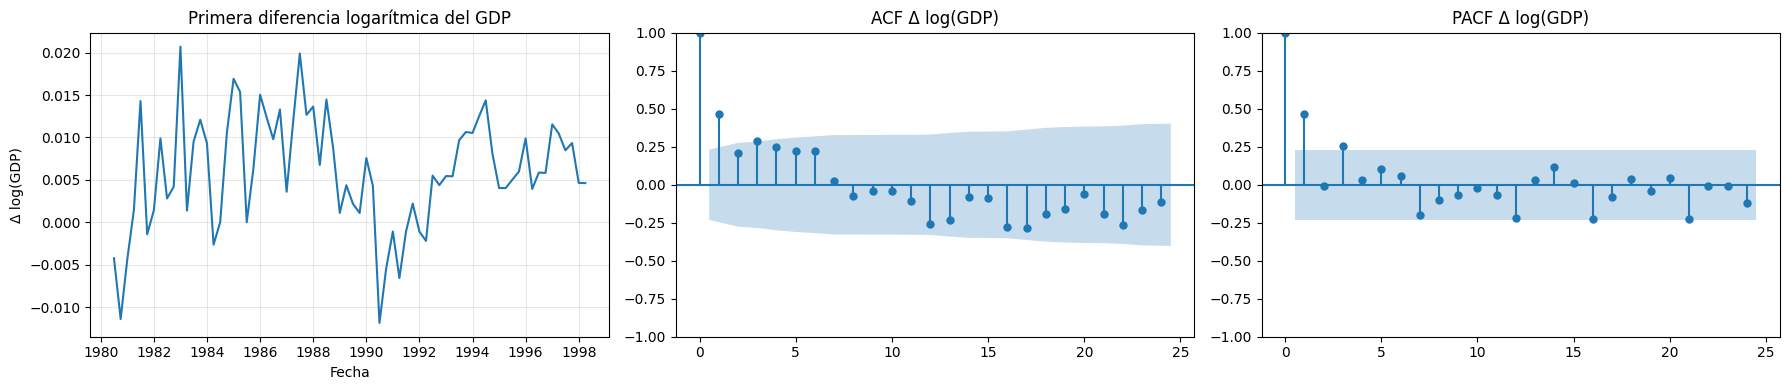

In [63]:
serie = df_gdp["dlog_gdp"].dropna()

fig, ax = plt.subplots(1, 3, figsize=(18, 4))
ax[0].plot(serie.index, serie)
ax[0].set_title("Primera diferencia logarítmica del GDP")
ax[0].set_xlabel("Fecha")
ax[0].set_ylabel("Δ log(GDP)")
ax[0].grid(True, alpha=0.3)

plot_acf(serie, lags=24, ax=ax[1])
ax[1].set_title("ACF Δ log(GDP)")

plot_pacf(serie, lags=24, ax=ax[2], method="ywm")
ax[2].set_title("PACF Δ log(GDP)")

plt.tight_layout()
plt.savefig(os.path.join(GRAPHICS_DIR, "grafico_2_Direfencia_Log_ACF_PACF.png"))
plt.show()

### Bloque 7 - Test ADF en diferencia logarítmica

In [64]:
adf_dlog = adfuller(df_gdp["dlog_gdp"].dropna(), autolag="AIC")

print("ADF Δ log(GDP)")
print("Estadístico ADF:", adf_dlog[0])
print("p-value:", adf_dlog[1])
print("Rechaza raíz unitaria al 5%:", adf_dlog[1] < 0.05)

ADF Δ log(GDP)
Estadístico ADF: -3.410069135498805
p-value: 0.010620367483719922
Rechaza raíz unitaria al 5%: True


## Respuesta B

Al tomar la primera diferencia logarítmica, la serie muestra menor persistencia que en nivel. El autocorrelograma deja de presentar un decaimiento lento y las autocorrelaciones tienden a disiparse más rápidamente.

Esto sugiere que la transformación Δ log(GDP) es más compatible con estacionariedad. Si el test ADF rechaza la hipótesis nula de raíz unitaria, entonces existe evidencia estadística de que la primera diferencia logarítmica es estacionaria.

# Pregunta C: Orden de integración y candidatos ARIMA
### Bloque 9 - Determinar orden de integración

In [65]:
orden_integracion = pd.DataFrame({
    "serie": ["GDP nivel", "Δ log(GDP)"],
    "ADF_stat": [adf_nivel[0], adf_dlog[0]],
    "p_value": [adf_nivel[1], adf_dlog[1]],
    "rechaza_raiz_unitaria_5pct": [adf_nivel[1] < 0.05, adf_dlog[1] < 0.05]
})

orden_integracion

,serie,ADF_stat,p_value,rechaza_raiz_unitaria_5pct
0,GDP nivel,-0.606667,0.869468,False
1,Δ log(GDP),-3.410069,0.010620,True


## Respuesta C

La evidencia sugiere que el GDP en nivel no es estacionario, mientras que la primera diferencia logarítmica presenta un comportamiento más compatible con estacionariedad.

Por lo tanto, la serie puede ser tratada como integrada de orden uno, es decir, I(1). En consecuencia, una estrategia adecuada es modelar el logaritmo del GDP mediante modelos ARIMA con d = 1, o equivalentemente modelar Δ log(GDP) mediante modelos ARMA.

En base a la ACF y PACF de la primera diferencia logarítmica, se proponen cuatro modelos candidatos:
- ARIMA(1,1,0)
- ARIMA(0,1,1)
- ARIMA(1,1,1)
- ARIMA(2,1,1)

# Pregunta D: Estimar modelos ARIMA candidatos
### Bloque 11 - Estimar 4 modelos ARIMA

In [66]:
modelos_candidatos = {
    "ARIMA(1,1,0)": (1, 1, 0),
    "ARIMA(0,1,1)": (0, 1, 1),
    "ARIMA(1,1,1)": (1, 1, 1),
    "ARIMA(2,1,1)": (2, 1, 1)
}

resultados_modelos = []
modelos_estimados = {}

y = df_gdp["log_gdp"].dropna()

for nombre, orden in modelos_candidatos.items():
    try:
        modelo = ARIMA(y, order=orden).fit()
        modelos_estimados[nombre] = modelo

        dw = durbin_watson(modelo.resid.dropna())

        resultados_modelos.append({
            "modelo": nombre,
            "orden": orden,
            "AIC": modelo.aic,
            "BIC": modelo.bic,
            "LogLik": modelo.llf,
            "Durbin_Watson": dw
        })

    except Exception as e:
        print(f"Error en {nombre}: {e}")

resultados_arima_df = pd.DataFrame(resultados_modelos).sort_values("AIC")
resultados_arima_df

,modelo,orden,AIC,BIC,LogLik,Durbin_Watson
2,"ARIMA(1,1,1)","(1, 1, 1)",-526.225285,-519.395287,266.112643,1.002117
0,"ARIMA(1,1,0)","(1, 1, 0)",-521.269779,-516.716447,262.634889,1.002185
3,"ARIMA(2,1,1)","(2, 1, 1)",-517.363833,-508.257168,262.681916,1.002176
1,"ARIMA(0,1,1)","(0, 1, 1)",-504.530349,-499.977017,254.265175,1.002076


### Bloque 12 - Seleccionar mejor modelo por AIC/BIC

In [67]:
mejor_modelo_nombre = resultados_arima_df.iloc[0]["modelo"]
mejor_modelo = modelos_estimados[mejor_modelo_nombre]

print("Mejor modelo seleccionado:", mejor_modelo_nombre)
print(mejor_modelo.summary())

Mejor modelo seleccionado: ARIMA(1,1,1)
                               SARIMAX Results                                
Dep. Variable:                log_gdp   No. Observations:                   73
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 266.113
Date:                Fri, 01 May 2026   AIC                           -526.225
Time:                        18:16:03   BIC                           -519.395
Sample:                    04-01-1980   HQIC                          -523.506
                         - 04-01-1998                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8772      0.077     11.321      0.000       0.725       1.029
ma.L1         -0.4654      0.164     -2.846      0.004      -0.786      -0.145
sigma2      

### Bloque 13 - Significancia de parámetros de todos los modelos

In [68]:
significancia_parametros = []

for nombre, modelo in modelos_estimados.items():
    params = modelo.params
    pvalues = modelo.pvalues

    for param in params.index:
        significancia_parametros.append({
            "modelo": nombre,
            "parametro": param,
            "coeficiente": params[param],
            "p_value": pvalues[param],
            "significativo_5pct": pvalues[param] < 0.05
        })

significancia_parametros_df = pd.DataFrame(significancia_parametros)
significancia_parametros_df

,modelo,parametro,coeficiente,p_value,significativo_5pct
0,"ARIMA(1,1,0)",ar.L1,0.710426,1.391082e-18,True
1,"ARIMA(1,1,0)",sigma2,0.000039,4.967740e-10,True
2,"ARIMA(0,1,1)",ma.L1,0.533347,1.014865e-07,True
3,"ARIMA(0,1,1)",sigma2,0.000050,1.511143e-07,True
4,"ARIMA(1,1,1)",ar.L1,0.877199,1.031311e-29,True
5,"ARIMA(1,1,1)",ma.L1,-0.465353,4.426653e-03,True
6,"ARIMA(1,1,1)",sigma2,0.000036,3.390387e-12,True
7,"ARIMA(2,1,1)",ar.L1,0.279997,9.210497e-01,False
8,"ARIMA(2,1,1)",ar.L2,0.307820,8.749484e-01,False
9,"ARIMA(2,1,1)",ma.L1,0.396047,8.896308e-01,False


### Bloque 14 - Significancia global del modelo seleccionado

In [69]:
pvalues_modelo = mejor_modelo.pvalues

parametros_dinamicos = [
    p for p in pvalues_modelo.index
    if ("ar." in p.lower()) or ("ma." in p.lower())
]

significativos = [
    p for p in parametros_dinamicos
    if pvalues_modelo[p] < 0.05
]

print("Modelo seleccionado:", mejor_modelo_nombre)
print("Parámetros dinámicos:", parametros_dinamicos)
print("Parámetros dinámicos significativos al 5%:", significativos)

if len(significativos) > 0:
    print("Conclusión: el modelo presenta evidencia de significancia global.")
else:
    print("Conclusión: no hay evidencia fuerte de significancia global en los parámetros dinámicos.")

Modelo seleccionado: ARIMA(1,1,1)
Parámetros dinámicos: ['ar.L1', 'ma.L1']
Parámetros dinámicos significativos al 5%: ['ar.L1', 'ma.L1']
Conclusión: el modelo presenta evidencia de significancia global.


## Significancia global del modelo

El modelo ARIMA seleccionado presenta evidencia de significancia global en la medida en que al menos uno de sus parámetros dinámicos autorregresivos o de medias móviles resulta estadísticamente significativo.

La significancia individual de los parámetros se evalúa mediante los p-values reportados en el `summary()`. Si los parámetros AR o MA son significativos, se concluye que el modelo incorpora información temporal útil para describir la dinámica de la serie.

Además, la selección mediante criterios de información como AIC y BIC respalda que esta especificación ofrece un mejor balance entre ajuste y parsimonia frente a las alternativas evaluadas.

## ¿Es buena idea usar R² para escoger entre modelos ARIMA?

No es recomendable utilizar el R² como criterio principal para comparar modelos ARIMA. En modelos de series de tiempo, especialmente cuando se trabaja con variables integradas o diferenciadas, el R² puede ser engañoso y favorecer modelos con mayor ajuste mecánico sin necesariamente mejorar la calidad del modelo.

Para modelos ARIMA es preferible utilizar criterios de información como AIC y BIC, porque penalizan la complejidad del modelo y permiten comparar especificaciones con distinto número de parámetros. También es importante revisar la significancia de los parámetros, el comportamiento de los residuos y la capacidad predictiva fuera de muestra.

### Bloque 17 - Ajuste dentro de muestra y residuos

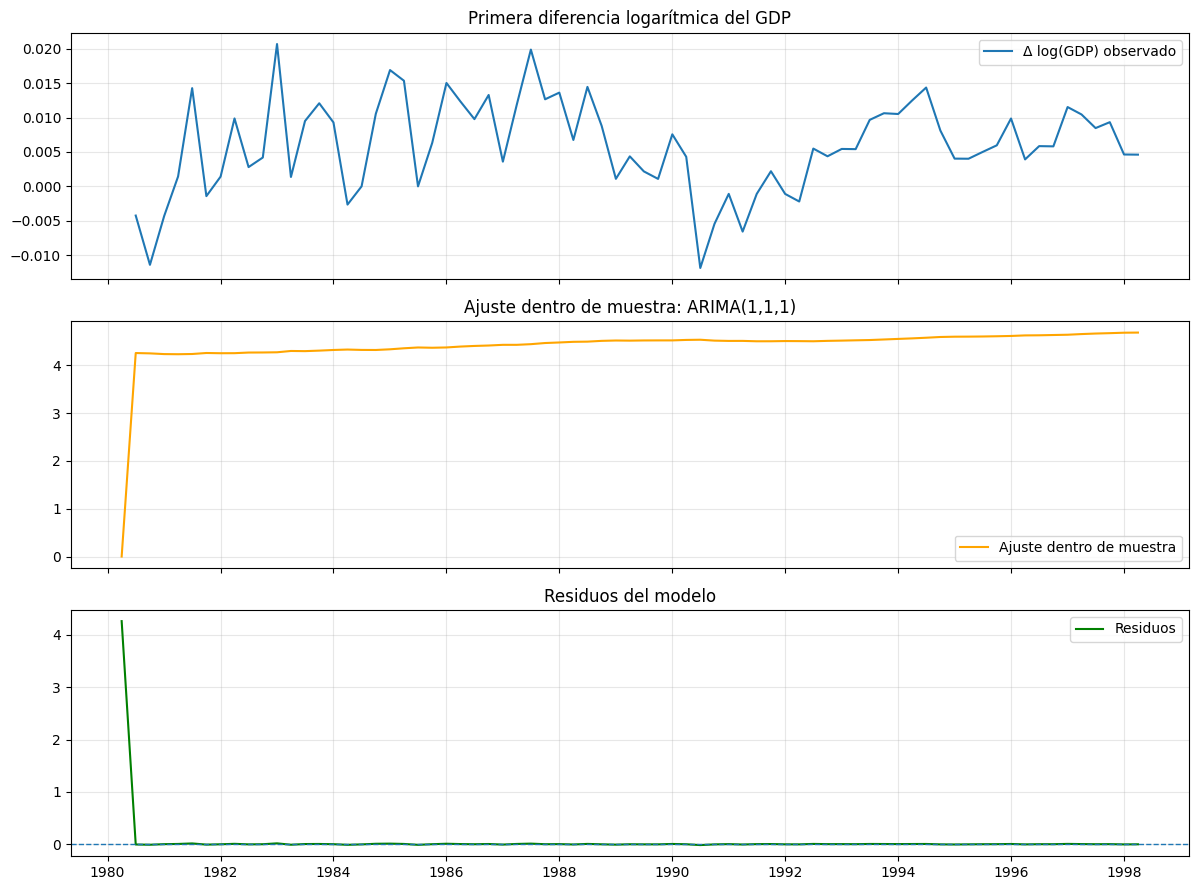

In [70]:
fitted_values = mejor_modelo.fittedvalues
residuos = mejor_modelo.resid

df_gdp["ajuste_modelo"] = fitted_values
df_gdp["residuos_modelo"] = residuos

fig, ax = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

ax[0].plot(df_gdp.index, df_gdp["dlog_gdp"], label="Δ log(GDP) observado")
ax[0].set_title("Primera diferencia logarítmica del GDP")
ax[0].legend()
ax[0].grid(True, alpha=0.3)

ax[1].plot(df_gdp.index, df_gdp["ajuste_modelo"], label="Ajuste dentro de muestra", color="orange")
ax[1].set_title(f"Ajuste dentro de muestra: {mejor_modelo_nombre}")
ax[1].legend()
ax[1].grid(True, alpha=0.3)

ax[2].plot(df_gdp.index, df_gdp["residuos_modelo"], label="Residuos", color="green")
ax[2].axhline(0, linestyle="--", linewidth=1)
ax[2].set_title("Residuos del modelo")
ax[2].legend()
ax[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(GRAPHICS_DIR, "grafico_3_Primera_diferencia_log_GDP.png"))
plt.show()

### Bloque 18 - Diagnóstico de residuos

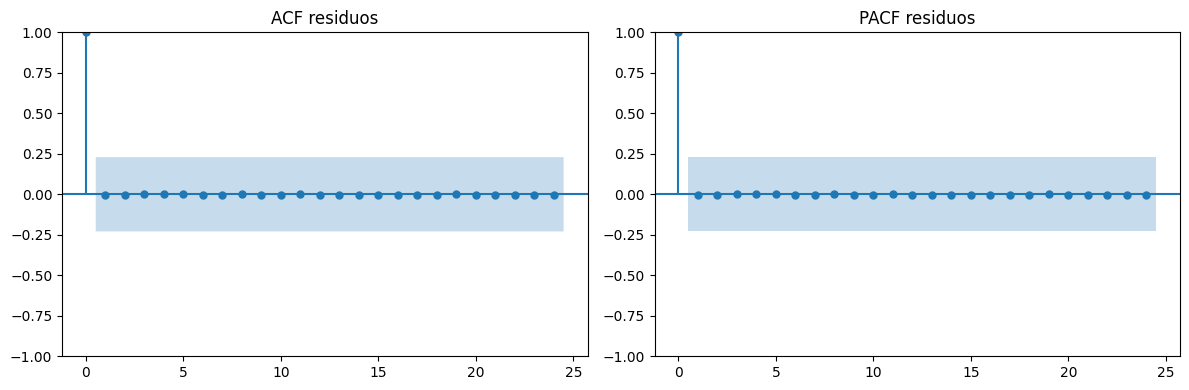

,lb_stat,lb_pvalue
4,0.000872,1.0
8,0.002362,1.0
12,0.005510,1.0


In [71]:
residuos_limpios = residuos.dropna()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(residuos_limpios, lags=24, ax=ax[0])
ax[0].set_title("ACF residuos")

plot_pacf(residuos_limpios, lags=24, ax=ax[1], method="ywm")
ax[1].set_title("PACF residuos")

plt.tight_layout()
plt.savefig(os.path.join(GRAPHICS_DIR, "grafico_4_Dicgnostico_de_Residuos.png"))
plt.show()

ljung_box = acorr_ljungbox(residuos_limpios, lags=[4, 8, 12], return_df=True)
ljung_box

## Respuesta D

Se estimaron cuatro modelos ARIMA candidatos y se compararon mediante criterios de información AIC y BIC. Estos criterios son más adecuados que el R² para seleccionar modelos de series de tiempo, ya que penalizan la complejidad del modelo.

La significancia de los parámetros se evaluó a partir de los p-values reportados en cada modelo. El modelo seleccionado corresponde a la especificación con mejor combinación de ajuste, parsimonia y comportamiento de residuos.

El estadístico Durbin-Watson permite evaluar autocorrelación serial en los residuos. Un valor cercano a 2 sugiere ausencia de autocorrelación de primer orden. Adicionalmente, los correlogramas ACF/PACF de los residuos y el test de Ljung-Box permiten evaluar si los residuos se comportan como ruido blanco.

Los residuos deberían fluctuar alrededor de cero, no presentar tendencia, no mostrar patrones sistemáticos y tener autocorrelaciones no significativas. Si esto se cumple, el modelo captura adecuadamente la estructura temporal de la serie.

# Pregunta E: Limitaciones del enfoque dentro de muestra
## Respuesta E

El análisis realizado hasta este punto corresponde a una estimación dentro de muestra, ya que los parámetros del modelo se estiman utilizando toda la información disponible. Esto permite evaluar ajuste histórico, pero no constituye un ejercicio predictivo real.

Si se quisiera pronosticar el GDP hacia el futuro, por ejemplo para 2022-2030, podrían surgir varios problemas. Primero, el modelo podría estar sobreajustado a la muestra histórica. Segundo, podrían existir cambios estructurales en la economía que alteren la dinámica futura del GDP. Tercero, la relación estimada puede no mantenerse estable fuera del período observado.

Por ello, un análisis fuera de muestra sería más adecuado para evaluar capacidad predictiva. En ese enfoque, se divide la muestra en una ventana de estimación y una ventana de evaluación. El modelo se estima con información disponible hasta cierto punto y luego se evalúa con datos posteriores no utilizados en la estimación.

Esto permite distinguir entre buen ajuste histórico y verdadera capacidad predictiva.

### Bloque 21 - Exportar resultados Parte 3

In [72]:
archivo_salida = os.path.join(TABLES_DIR, "resultados_parte_3.xlsx")

with pd.ExcelWriter(archivo_salida) as writer:
    orden_integracion.to_excel(writer, sheet_name="ADF", index=False)
    resultados_arima_df.to_excel(writer, sheet_name="Modelos_ARIMA", index=False)
    significancia_parametros_df.to_excel(writer, sheet_name="Significancia", index=False)
    ljung_box.to_excel(writer, sheet_name="Ljung_Box")

print("Archivo exportado correctamente:")
print(archivo_salida)

Archivo exportado correctamente:
C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0011\Tarea Final\results\tables\parte3\resultados_parte_3.xlsx


## Conclusión general Parte 3

La metodología Box-Jenkins permitió analizar la dinámica trimestral del GDP de UK. En primer lugar, la serie en nivel mostró alta persistencia y un autocorrelograma con decaimiento lento, lo que sugiere no estacionariedad. Luego, al trabajar con la primera diferencia logarítmica, la serie mostró un comportamiento más compatible con estacionariedad.

A partir de este análisis, se concluye que el GDP puede tratarse como una serie integrada de orden uno, I(1), por lo que se estimaron modelos ARIMA con una diferencia. Se compararon cuatro especificaciones candidatas mediante AIC y BIC, significancia de parámetros, significancia global, estadístico Durbin-Watson y diagnóstico de residuos.

El modelo seleccionado corresponde a la especificación que presenta el mejor balance entre ajuste, parsimonia y residuos compatibles con ruido blanco. Finalmente, se reconoce que este análisis es dentro de muestra, por lo que para evaluar capacidad predictiva real sería necesario implementar una evaluación fuera de muestra.

### Bloque Python para exportar tablas a LaTeX

In [73]:
import os

LATEX_DIR = os.path.join(RESULTS_DIR, "latex_tables")
os.makedirs(LATEX_DIR, exist_ok=True)

def exportar_tabla_latex(df, nombre_archivo, caption, label, columnas=None, n=10):
    tabla = df.copy()
    
    if columnas is not None:
        tabla = tabla[columnas]
    
    tabla = tabla.head(n)
    
    ruta = os.path.join(LATEX_DIR, nombre_archivo)
    
    latex = tabla.to_latex(
        index=False,
        float_format="%.4f",
        caption=caption,
        label=label,
        escape=False,
        longtable=False,
        bold_rows=False
    )
    
    with open(ruta, "w", encoding="utf-8") as f:
        f.write(latex)
    
    print(f"Tabla exportada: {ruta}")

### Exportar tablas

In [74]:
exportar_tabla_latex(
    orden_integracion,
    "tabla_adf_gdp.tex",
    "Test ADF para GDP en nivel y diferencia logarítmica",
    "tab:adf_gdp"
)

exportar_tabla_latex(
    resultados_arima_df,
    "tabla_modelos_arima.tex",
    "Comparación de modelos ARIMA candidatos",
    "tab:arima"
)

exportar_tabla_latex(
    significancia_parametros_df,
    "tabla_significancia_arima.tex",
    "Significancia de parámetros de modelos ARIMA",
    "tab:significancia_arima"
)

exportar_tabla_latex(
    ljung_box.reset_index(),
    "tabla_ljung_box.tex",
    "Test Ljung-Box sobre residuos del modelo ARIMA",
    "tab:ljung_box"
)

Tabla exportada: C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0011\Tarea Final\results\latex_tables\tabla_adf_gdp.tex
Tabla exportada: C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0011\Tarea Final\results\latex_tables\tabla_modelos_arima.tex
Tabla exportada: C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0011\Tarea Final\results\latex_tables\tabla_significancia_arima.tex
Tabla exportada: C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0011\Tarea Final\results\latex_tables\tabla_ljung_box.tex
